# Lellouch SAFOD Trace Frequency Content

This notebook checks the frequency content of the released Lellouch et al. SAFOD ambient-noise cross-correlation traces. It uses the `.npy` trace files from the paper repository, so it does not require ObsPy.

On Sherlock, set `TRACE_DIR` to wherever you copy the `traces/` folder.

In [1]:
import os
import glob
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "figure.dpi": 120,
})

## User Settings

`FS = 500 Hz` is inferred from the released `.npy` traces and the miniSEED headers. The `.npy` traces have 1901 samples, so this gives a lag axis of about `-1.9` to `+1.9` seconds.

In [2]:
# Local Mac path:
# TRACE_DIR = "/Users/nberrios/Downloads/traces"


# Example Sherlock path after copying the folder there:
TRACE_DIR = "/home/groups/ettore88/nberrios/safod_das_git/lellouch_traces"

FIG_DIR = "/home/groups/ettore88/nberrios/safod_das_git/notebooks/figures/lellouch_frequency_content"

# If running locally and the Sherlock figure path does not exist, fall back to a local output folder.
if not os.path.isdir(os.path.dirname(FIG_DIR)):
    FIG_DIR = os.path.join(os.getcwd(), "figures", "lellouch_frequency_content")

FS = 500.0
DT = 1.0 / FS

FREQ_BAND = (5.0, 20.0)
MAX_FREQ_SHOW = 80.0

os.makedirs(FIG_DIR, exist_ok=True)
print("TRACE_DIR:", TRACE_DIR)
print("FIG_DIR:", FIG_DIR)

TRACE_DIR: /home/groups/ettore88/nberrios/safod_das_git/lellouch_traces
FIG_DIR: /home/groups/ettore88/nberrios/safod_das_git/notebooks/figures/lellouch_frequency_content


## Load Released `.npy` Traces

In [3]:
def depth_from_name(path):
    name = os.path.basename(path)
    m = re.search(r"(\d+)m\.npy$", name)
    return int(m.group(1)) if m else np.nan

trace_files = sorted(glob.glob(os.path.join(TRACE_DIR, "*m.npy")), key=depth_from_name)
print(f"Found {len(trace_files)} .npy trace files")
for f in trace_files:
    print(os.path.basename(f), np.load(f).shape)

if not trace_files:
    raise FileNotFoundError(f"No '*m.npy' files found in TRACE_DIR={TRACE_DIR!r}")

traces = []
for f in trace_files:
    traces.append({
        "path": f,
        "name": os.path.splitext(os.path.basename(f))[0],
        "depth_m": depth_from_name(f),
        "data": np.load(f).astype(float),
    })

npts = len(traces[0]["data"])
lag = (np.arange(npts) - npts // 2) * DT
print("npts:", npts)
print("lag range:", lag[0], "to", lag[-1], "s")

Found 14 .npy trace files
050m.npy (1901,)
100m.npy (1901,)
150m.npy (1901,)
200m.npy (1901,)
250m.npy (1901,)
300m.npy (1901,)
350m.npy (1901,)
400m.npy (1901,)
450m.npy (1901,)
500m.npy (1901,)
550m.npy (1901,)
600m.npy (1901,)
650m.npy (1901,)
700m.npy (1901,)
npts: 1901
lag range: -1.9000000000000001 to 1.9000000000000001 s


## Plot Released CC Traces

This shows whether the released traces have coherent arrivals and what lag range they occupy.

Saved: /home/groups/ettore88/nberrios/safod_das_git/notebooks/figures/lellouch_frequency_content/lellouch_released_traces.png


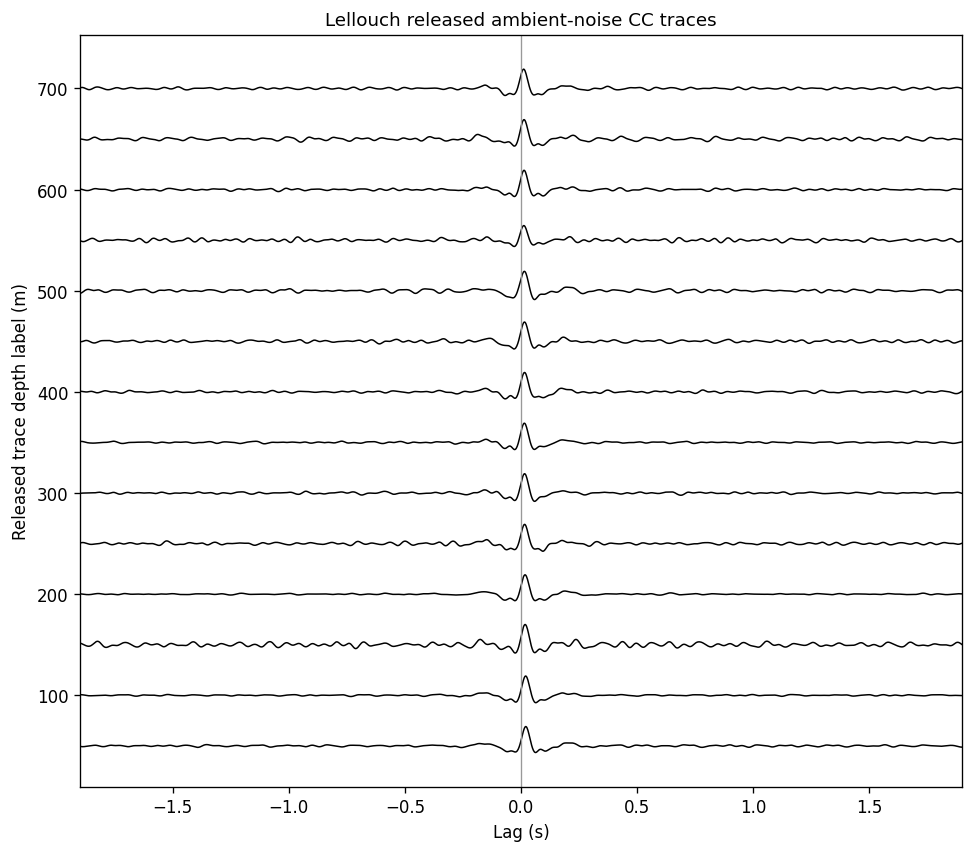

In [4]:
fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)

scale = max(np.nanmax(np.abs(t["data"])) for t in traces)
scale = scale if scale > 0 else 1.0

for t in traces:
    y = t["data"] / scale
    ax.plot(lag, y * 20 + t["depth_m"], color="black", lw=0.9)

ax.axvline(0, color="0.6", lw=0.8)
ax.set_xlabel("Lag (s)")
ax.set_ylabel("Released trace depth label (m)")
ax.set_title("Lellouch released ambient-noise CC traces")
ax.set_xlim(-1.9, 1.9)

out = os.path.join(FIG_DIR, "lellouch_released_traces.png")
fig.savefig(out, dpi=200)
print("Saved:", out)

## Compute Spectra

Each trace is demeaned and Hann tapered before FFT. The blue band marks the paper's stated `5-20 Hz` filter band.

In [5]:
def amplitude_spectrum(y, dt):
    y = np.asarray(y, dtype=float)
    y = y - np.nanmean(y)
    y = np.nan_to_num(y)
    y = y * np.hanning(len(y))
    freqs = np.fft.rfftfreq(len(y), d=dt)
    amp = np.abs(np.fft.rfft(y))
    return freqs, amp

spectra = []
for t in traces:
    freqs, amp = amplitude_spectrum(t["data"], DT)
    spectra.append({"depth_m": t["depth_m"], "name": t["name"], "freqs": freqs, "amp": amp})

print("Frequency spacing:", freqs[1] - freqs[0], "Hz")
print("Nyquist:", freqs[-1], "Hz")

Frequency spacing: 0.2630194634402946 Hz
Nyquist: 249.86849026827986 Hz


Saved: /home/groups/ettore88/nberrios/safod_das_git/notebooks/figures/lellouch_frequency_content/lellouch_individual_spectra.png


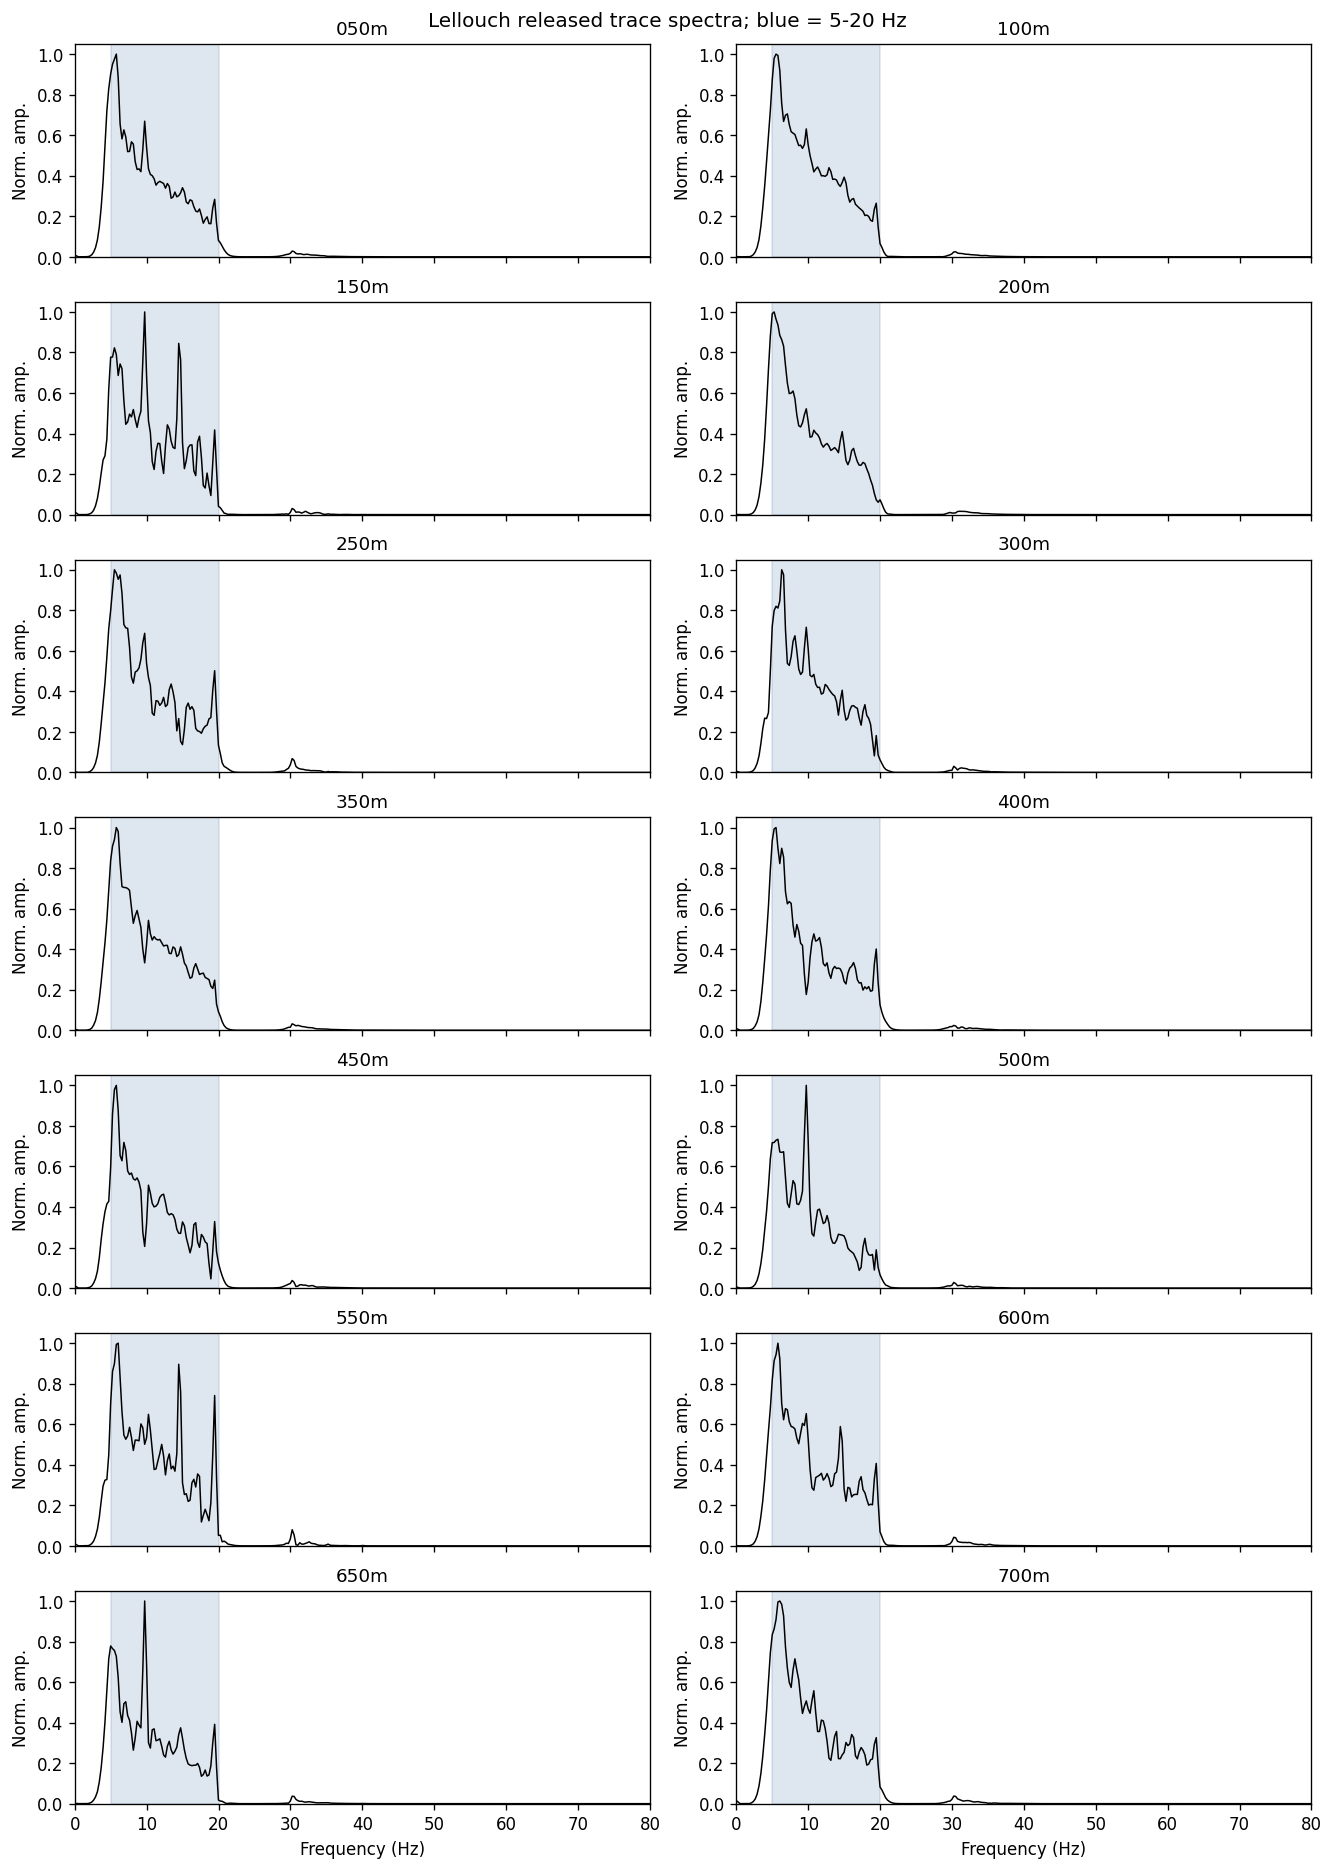

In [6]:
ncols = 2
nrows = int(np.ceil(len(spectra) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 2.2 * nrows), sharex=True, constrained_layout=True)
axes = np.ravel(axes)

for ax, s in zip(axes, spectra):
    amp = s["amp"] / max(np.nanmax(s["amp"]), 1e-12)
    ax.plot(s["freqs"], amp, color="black", lw=0.9)
    ax.axvspan(FREQ_BAND[0], FREQ_BAND[1], color="#4C78A8", alpha=0.18)
    ax.set_xlim(0, MAX_FREQ_SHOW)
    ax.set_ylim(0, 1.05)
    ax.set_title(s["name"])
    ax.set_ylabel("Norm. amp.")

for ax in axes[len(spectra):]:
    ax.axis("off")

for ax in axes[-ncols:]:
    ax.set_xlabel("Frequency (Hz)")

fig.suptitle("Lellouch released trace spectra; blue = 5-20 Hz", y=1.002)
out = os.path.join(FIG_DIR, "lellouch_individual_spectra.png")
fig.savefig(out, dpi=200, bbox_inches="tight")
print("Saved:", out)

## Average Spectrum and Band-Energy Check

This is a quick quantitative check: what fraction of spectral power lies in `5-20 Hz`?

In [7]:
rows = []
all_amp_norm = []

for s in spectra:
    freqs = s["freqs"]
    amp = s["amp"]
    power = amp ** 2
    band = (freqs >= FREQ_BAND[0]) & (freqs <= FREQ_BAND[1])
    shown = (freqs >= 0) & (freqs <= MAX_FREQ_SHOW)
    frac_5_20_of_0_80 = power[band].sum() / power[shown].sum()
    peak_freq = freqs[np.argmax(amp)]
    rows.append({
        "trace": s["name"],
        "depth_m": s["depth_m"],
        "peak_freq_hz": peak_freq,
        "power_fraction_5_20_of_0_80": frac_5_20_of_0_80,
    })
    all_amp_norm.append(amp / max(np.nanmax(amp), 1e-12))

summary = pd.DataFrame(rows).sort_values("depth_m")
display(summary)

csv_out = os.path.join(FIG_DIR, "lellouch_frequency_summary.csv")
summary.to_csv(csv_out, index=False)
print("Saved:", csv_out)

,trace,depth_m,peak_freq_hz,power_fraction_5_20_of_0_80
0,050m,50,5.786428,0.817460
1,100m,100,5.523409,0.869236
2,150m,150,9.731720,0.902739
3,200m,200,5.260389,0.815495
4,250m,250,5.523409,0.878997
5,300m,300,6.312467,0.926267
6,350m,350,5.786428,0.880832
7,400m,400,5.523409,0.836084
8,450m,450,5.786428,0.917426
9,500m,500,9.731720,0.866476


Saved: /home/groups/ettore88/nberrios/safod_das_git/notebooks/figures/lellouch_frequency_content/lellouch_frequency_summary.csv


Saved: /home/groups/ettore88/nberrios/safod_das_git/notebooks/figures/lellouch_frequency_content/lellouch_mean_spectrum.png


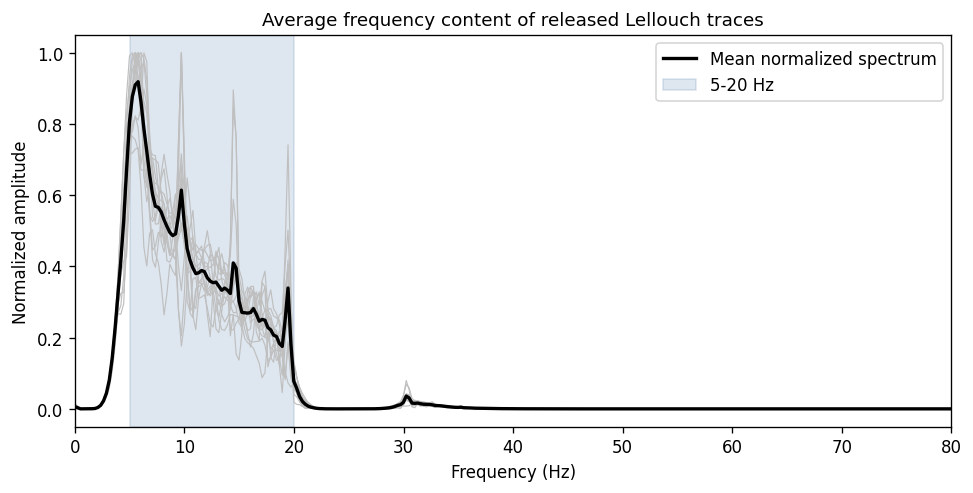

In [8]:
mean_amp = np.mean(np.vstack(all_amp_norm), axis=0)

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
for s, amp_norm in zip(spectra, all_amp_norm):
    ax.plot(s["freqs"], amp_norm, color="0.75", lw=0.7)
ax.plot(freqs, mean_amp, color="black", lw=2.0, label="Mean normalized spectrum")
ax.axvspan(FREQ_BAND[0], FREQ_BAND[1], color="#4C78A8", alpha=0.18, label="5-20 Hz")
ax.set_xlim(0, MAX_FREQ_SHOW)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Normalized amplitude")
ax.set_title("Average frequency content of released Lellouch traces")
ax.legend()

out = os.path.join(FIG_DIR, "lellouch_mean_spectrum.png")
fig.savefig(out, dpi=200)
print("Saved:", out)

## Parkfield Seismicity During the Lellouch Deployment Window

The paper states that the SAFOD DAS deployment was during June-July 2017, but it does not list the exact seven one-day windows used for the released ambient-noise correlations. This section queries events within a configurable radius around Parkfield over the broad June-July 2017 window.

In [9]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

PARKFIELD_LAT = 35.9747
PARKFIELD_LON = -120.5522
RADIUS_KM = 20.0
MIN_MAG = 1.0

# Broad window from the paper: about one month during June-July 2017.
# Use this as the comparison window because the exact seven days are not reported.
SEIS_START = "2017-06-01"
SEIS_END = "2017-08-01"  # exclusive-ish FDSN end time

CATALOG_CLIENTS = ["NCEDC", "USGS"]

MAG_BINS = [1.0, 2.0, 3.0, 4.0, 10.0]
MAG_LABELS = ["M1-2", "M2-3", "M3-4", "M4+"]
MAG_COLORS = ["#1B3A4B", "#4F6D7A", "#A7BBC7", "#EAF2F8"]

print(f"Query window: {SEIS_START} to {SEIS_END} UTC")
print(f"Radius: {RADIUS_KM} km around Parkfield; minimum magnitude: M{MIN_MAG}")

Query window: 2017-06-01 to 2017-08-01 UTC
Radius: 20.0 km around Parkfield; minimum magnitude: M1.0


In [10]:
def fetch_events_near_parkfield():
    last_error = None
    for client_name in CATALOG_CLIENTS:
        try:
            client = Client(client_name)
            cat = client.get_events(
                starttime=UTCDateTime(SEIS_START),
                endtime=UTCDateTime(SEIS_END),
                latitude=PARKFIELD_LAT,
                longitude=PARKFIELD_LON,
                maxradius=RADIUS_KM / 111.19,
                minmagnitude=MIN_MAG,
            )
            print(f"Fetched {len(cat)} events from {client_name}")
            return client_name, cat
        except Exception as exc:
            print(f"{client_name} query failed: {exc}")
            last_error = exc
    raise RuntimeError(f"All catalog clients failed. Last error: {last_error}")

catalog_name, catalog = fetch_events_near_parkfield()

event_rows = []
for ev in catalog:
    origin = ev.preferred_origin() or ev.origins[0]
    mag = ev.preferred_magnitude() or ev.magnitudes[0]
    event_rows.append({
        "time": pd.Timestamp(str(origin.time.datetime), tz="UTC"),
        "latitude": origin.latitude,
        "longitude": origin.longitude,
        "depth_km": origin.depth / 1000.0 if origin.depth is not None else np.nan,
        "magnitude": mag.mag,
        "magnitude_type": mag.magnitude_type,
        "event_id": str(ev.resource_id),
    })

events = pd.DataFrame(event_rows).sort_values("time").reset_index(drop=True)
events["mag_bin"] = pd.cut(events["magnitude"], bins=MAG_BINS, labels=MAG_LABELS, right=False)

csv_out = os.path.join(FIG_DIR, f"parkfield_{catalog_name}_M{MIN_MAG:g}_{RADIUS_KM:g}km_{SEIS_START}_{SEIS_END}.csv")
events.to_csv(csv_out, index=False)
print("Saved:", csv_out)
display(events.head())
print("Total events:", len(events))

Fetched 18 events from NCEDC
Saved: /home/groups/ettore88/nberrios/safod_das_git/notebooks/figures/lellouch_frequency_content/parkfield_NCEDC_M1_20km_2017-06-01_2017-08-01.csv


,time,latitude,longitude,depth_km,magnitude,magnitude_type,event_id,mag_bin
0,2017-06-03 12:54:12.570000+00:00,35.998333,-120.554667,1.94,1.06,Md,quakeml:NC.anss.org/Event/NC/72809891,M1-2
1,2017-06-14 21:40:36.530000+00:00,36.031667,-120.598333,3.24,1.18,Md,quakeml:NC.anss.org/Event/NC/72815966,M1-2
2,2017-06-23 22:09:01.800000+00:00,36.078000,-120.655000,2.09,1.47,Md,quakeml:NC.anss.org/Event/NC/72820181,M1-2
3,2017-06-26 23:13:54.340000+00:00,35.973500,-120.531333,10.50,1.33,Md,quakeml:NC.anss.org/Event/NC/72821956,M1-2
4,2017-06-30 15:05:13+00:00,35.968333,-120.524167,10.75,2.46,Md,quakeml:NC.anss.org/Event/NC/72824251,M2-3


Total events: 18


/tmp/ipykernel_9872/2037362555.py:22: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.autofmt_xdate(rotation=30, ha="right")


Saved: /home/groups/ettore88/nberrios/safod_das_git/notebooks/figures/lellouch_frequency_content/parkfield_seismicity_hist_NCEDC_M1_20km_2017-06-01_2017-08-01.png


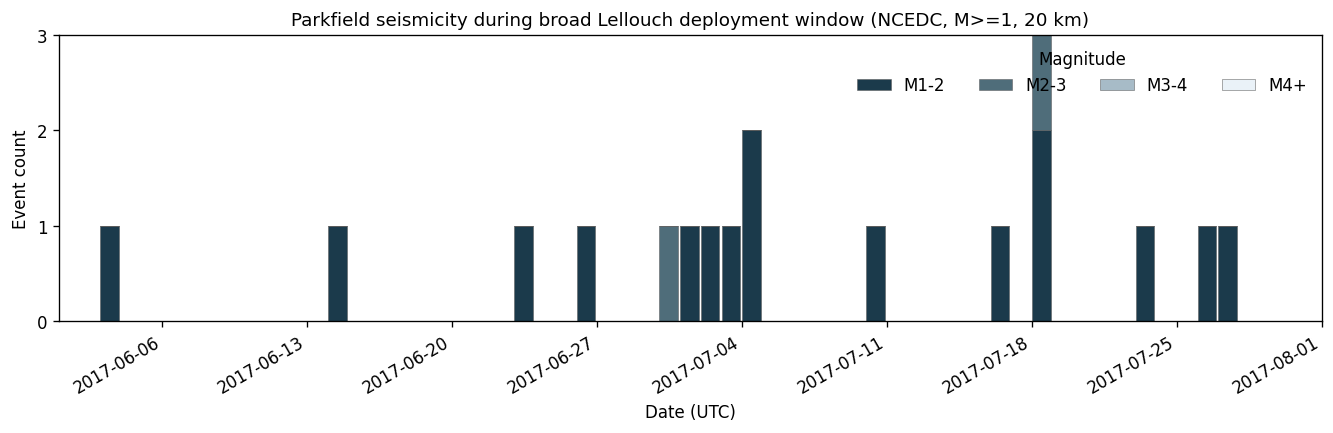

In [11]:
fig, ax = plt.subplots(figsize=(11, 3.5), constrained_layout=True)

start = pd.Timestamp(SEIS_START, tz="UTC")
end = pd.Timestamp(SEIS_END, tz="UTC")
daily_edges = pd.date_range(start, end, freq="1D")

bottom = np.zeros(len(daily_edges) - 1, dtype=int)
for label, color in zip(MAG_LABELS, MAG_COLORS):
    subset = events[events["mag_bin"] == label]
    counts, _ = np.histogram(subset["time"].astype("int64"), bins=daily_edges.astype("int64"))
    ax.bar(daily_edges[:-1], counts, bottom=bottom, width=0.9, align="edge", color=color, edgecolor="0.35", linewidth=0.3, label=label)
    bottom += counts

ax.set_title(f"Parkfield seismicity during broad Lellouch deployment window ({catalog_name}, M>={MIN_MAG:g}, {RADIUS_KM:g} km)")
ax.set_xlabel("Date (UTC)")
ax.set_ylabel("Event count")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.set_xlim(start, end)
ax.legend(title="Magnitude", ncols=len(MAG_LABELS), frameon=False, loc="upper right")
fig.autofmt_xdate(rotation=30, ha="right")

out = os.path.join(FIG_DIR, f"parkfield_seismicity_hist_{catalog_name}_M{MIN_MAG:g}_{RADIUS_KM:g}km_{SEIS_START}_{SEIS_END}.png")
fig.savefig(out, dpi=200)
print("Saved:", out)

## Interpretation Notes

- The seismicity histogram uses the broad June-July 2017 deployment window because the paper does not report the exact seven days used for the released traces.
- If most power is concentrated in `5-20 Hz`, the released traces are consistent with the paper's stated post-correlation bandpass.
- If substantial power appears outside `5-20 Hz`, that does not automatically mean the paper is wrong. It could come from finite trace length, tapering, plotting the released data before final filtering, or numerical differences.
- The paper does not provide the exact seven one-day windows used, so these traces are a morphology target, not a fully reproducible benchmark.